# Production Pipeline: Color Extraction for All Products

Applies the full three-stage extraction pipeline to all ~9k product images, using the same shared `src/` modules (`classify.py`, `segment.py`, `extract_color.py`, `pipeline.py`) so routing/extraction logic can't drift between notebooks that need it:

1. **Stage 1: Classify** each image with the ResNet-18 classifier (`06_a`) into one of the seven trained classes → `bullet`, `closed`, `lips`, `liquid`, `pencil`, `swatch`, `unclassifiable`
2. **Stage 2: Segment** the color region with the matching U-Net (`06_b`), routed by predicted type:
   - `bullet` / `liquid` / `pencil` → combined segmenter (`unet_segmenter.pth`)
   - `closed` → `unet_segmenter_other.pth`
   - `swatch` → `unet_swatch.pth`
   - `lips` → `unet_lips.pth`
   - `unclassifiable`, or prediction confidence below `CLF_THRESHOLD` (0.6) → no segmentation, no extraction
3. **Stage 3: Extract color** from the masked region:
   - `closed` → dominant cluster LAB (resists glare/reflection through transparent packaging)
   - `bullet`, `liquid`, `pencil`, `swatch`, `lips` → median LAB from masked pixels
4. **Post-process** → LAB → hex, color circle HTML, color grouping for app filtering
5. **Save** `data/processed/products_pipeline.csv`


# Libraries

In [1]:
import os
import sys
import warnings
from datetime import datetime, timezone
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from skimage import color as skcolor
import torch
from sklearn.mixture import GaussianMixture
warnings.filterwarnings('ignore')


# Setup

Paths, config, and image indexing for running every product image through the models: classify (Stage 1), segment (Stage 2), and extract color (Stage 3). No annotation or processed-metadata files are needed here — those are only touched later, when joining product metadata and saving the final output.

Also puts the repo root on `sys.path` so the shared model-loading and routing code in `src/` (`classify.py`, `segment.py`, `extract_color.py`, `pipeline.py`) can be imported.


In [2]:
BASE       = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
IMG_DIR    = os.path.join(BASE, 'data', 'img', 'original_clean')
MODELS_DIR = os.path.join(BASE, 'models')

if BASE not in sys.path:
    sys.path.insert(0, BASE)

RANDOM_SEED = 42
DEVICE      = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'device : {DEVICE}')
print(f'images in original_clean: {len(os.listdir(IMG_DIR))}')


device : mps
images in original_clean: 9153


# Product Data

In [3]:
# Scan all images in original_clean directly
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
img_fnames = sorted([f for f in os.listdir(IMG_DIR) if os.path.splitext(f)[1].lower() in IMG_EXTS])

img_df = pd.DataFrame({
    'img_name': img_fnames,
    'img_path': [os.path.join(IMG_DIR, f) for f in img_fnames],
})

print(f'{len(img_df)} images found in {IMG_DIR}')

9153 images found in /Users/connie/dev/lipstick_color_extraction/data/img/original_clean


# Load Models

Classifier and the four segmenters, loaded through the shared `src/` model code (`src/classify.py`, `src/segment.py`) rather than rebuilt inline, so architecture/checkpoint mismatches can't creep in separately here.


In [4]:
# Shared model-loading + routing code from src/, so classifier/segmenter
# loading and type routing can't drift between notebooks that need it.
from src.classify import load_classifier
from src.segment import load_segmenter
from src.pipeline import route_and_extract

CLF_THRESHOLD = 0.6

# Classes always come from the checkpoint's own 'classes' key, never
# hardcoded — a hardcoded list that drifts from the checkpoint has silently
# misrouted predictions before (see CLAUDE.md).
clf, CLASSES = load_classifier(os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth'), device=DEVICE)

seg        = load_segmenter(os.path.join(MODELS_DIR, 'unet_segmenter.pth'), device=DEVICE)
seg_other  = load_segmenter(os.path.join(MODELS_DIR, 'unet_segmenter_other.pth'), device=DEVICE)
seg_swatch = load_segmenter(os.path.join(MODELS_DIR, 'unet_swatch.pth'), device=DEVICE)
seg_lips   = load_segmenter(os.path.join(MODELS_DIR, 'unet_lips.pth'), device=DEVICE)

# Keyed by role, not filename — this is what route_and_extract expects.
segmenters = {'main': seg, 'closed': seg_other, 'swatch': seg_swatch, 'lips': seg_lips}

print(f'classifier loaded — classes: {CLASSES}')
print('4 segmenters loaded — ready for inference')


classifier loaded — classes: ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']
4 segmenters loaded — ready for inference


# Stage 1: Classify All Images

Batch inference through ResNet-18 to predict image type for every product, across all seven trained classes (`bullet`, `closed`, `lips`, `liquid`, `pencil`, `swatch`, `unclassifiable`), via `src/classify_batch.py`'s `predict_batch` (a DataLoader-batched counterpart to `src/classify.py`'s single-image `predict`).


In [5]:
from src.classify_batch import predict_batch

paths = img_df['img_path'].tolist()
print(f'Classifying {len(paths)} images...')
pred_labels, pred_confidences = predict_batch(clf, paths, CLASSES, device=DEVICE)

img_df['pred_label']      = pred_labels
img_df['pred_confidence'] = pred_confidences

# Confidence safety net: low-confidence predictions are routed to
# 'unclassifiable' rather than trusted, since confidence isn't a reliable
# proxy for out-of-distribution images either way (see CLAUDE.md).
img_df['routed_label'] = np.where(
    img_df['pred_confidence'] >= CLF_THRESHOLD, img_df['pred_label'], 'unclassifiable'
)

print('\nPredicted label distribution:')
print(img_df['pred_label'].value_counts().to_string())
print('\nRouted label distribution (after CLF_THRESHOLD safety net):')
print(img_df['routed_label'].value_counts().to_string())


Classifying 9153 images...


images classified:   0%|          | 0/144 [00:00<?, ?batch/s]


Predicted label distribution:
pred_label
swatch            3737
bullet            3144
liquid            1362
closed             291
pencil             281
unclassifiable     270
lips                68

Routed label distribution (after CLF_THRESHOLD safety net):
routed_label
swatch            3695
bullet            3024
liquid            1310
unclassifiable     566
pencil             250
closed             243
lips                65


# Stage 2 & 3: Segment and Extract Color per Image

For each image, `route_and_extract(img_path, routed_label, segmenters, device)` (`src/pipeline.py`) does both steps in one call: it picks the segmenter for `routed_label`, runs it to predict a binary color-region mask (Stage 2 — this is where mask prediction actually happens, inside `route_and_extract` itself, not as a separate step in this notebook), then immediately extracts a single CIELAB color from the pixels inside that mask (Stage 3). It returns `(mask, lab)`; the loop below keeps only `lab`, since the mask itself isn't needed downstream.

Routing by `routed_label`:
- `bullet` / `liquid` / `pencil` → combined U-Net mask → median LAB
- `closed` → separate U-Net mask → dominant cluster LAB (resists glare/reflection)
- `swatch` → U-Net mask → median LAB
- `lips` → U-Net mask → median LAB
- `unclassifiable` → no extraction


In [6]:
L_vals, a_vals, b_vals = [], [], []

for _, row in tqdm(img_df.iterrows(), total=len(img_df), desc='extracting color'):
    try:
        _, lab = route_and_extract(row['img_path'], row['routed_label'], segmenters, DEVICE)
    except Exception:
        lab = np.full(3, np.nan)
    L_vals.append(float(lab[0]))
    a_vals.append(float(lab[1]))
    b_vals.append(float(lab[2]))

img_df['L'] = L_vals
img_df['a'] = a_vals
img_df['b'] = b_vals

print(f'Color extracted: {img_df["L"].notna().sum()} / {len(img_df)}')


extracting color:   0%|          | 0/9153 [00:00<?, ?it/s]

Color extracted: 8437 / 9153


# Post-processing

Convert LAB → RGB → hex and generate the HTML color circle used in the app, via `src/color_display.py`'s `lab_to_hex` and `make_circle`.


In [7]:
from src.color_display import lab_to_hex, make_circle

valid = img_df['L'].notna()
img_df.loc[valid, 'hex_color'] = img_df[valid].apply(
    lambda r: lab_to_hex(r['L'], r['a'], r['b']), axis=1
)
img_df.loc[valid, 'Circle'] = img_df.loc[valid, 'hex_color'].apply(make_circle)

print(f'{valid.sum()} rows with hex color')
img_df[['img_name', 'pred_label', 'L', 'a', 'b', 'hex_color', 'Circle']].head(4)


8437 rows with hex color


,img_name,pred_label,L,a,b,hex_color,Circle
0,lipstick__100_pure__fruit_pigmented_cocoa_butt...,swatch,31.463896,44.483480,26.707630,#8c2123,"<div style=""width:20px; height:20px; border-ra..."
1,lipstick__100_pure__fruit_pigmented_cocoa_butt...,bullet,38.346487,25.658965,17.485453,#88493f,"<div style=""width:20px; height:20px; border-ra..."
2,lipstick__100_pure__fruit_pigmented_cocoa_butt...,bullet,53.785172,34.328566,19.314478,#bf6761,"<div style=""width:20px; height:20px; border-ra..."
3,lipstick__100_pure__fruit_pigmented_cocoa_butt...,bullet,50.026892,33.171770,9.517342,#af6068,"<div style=""width:20px; height:20px; border-ra..."


# Color Grouping

Cluster all extracted colors into a small representative palette using a **Gaussian Mixture Model (GMM)** in LAB space. GMM fits ellipsoidal clusters, which better captures the uneven shape of lipstick color distributions (e.g., the dense nude/pink/red region vs. sparse purples and browns) compared to k-means spheres.

**BIC (Bayesian Information Criterion)** Rely on smaller BIC to select number of groups. 

In [8]:
color_df = img_df[img_df['L'].notna()].copy()
X = color_df[['L', 'a', 'b']].values

# BIC picks the statistically optimal k, but it finds ~10 because reds/pinks dominate.
# Force a larger k so rare colors (blues, greens, dark burgundies) get their own groups.
k_opt = 25  # adjust up or down after seeing the palette

print(f'Using k={k_opt} color groups')

Using k=25 color groups


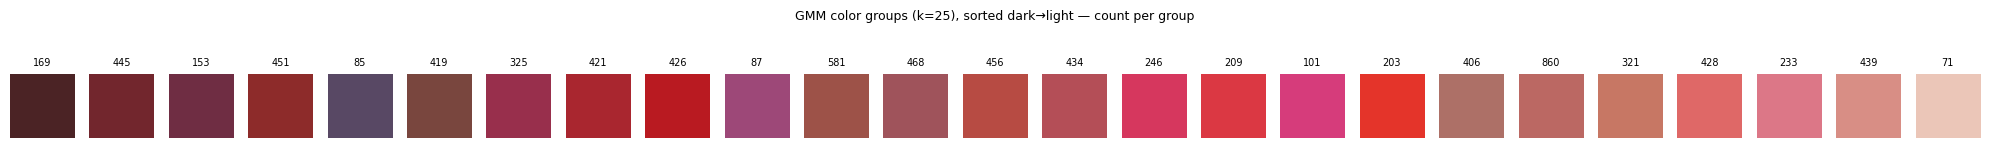

In [9]:
gmm = GaussianMixture(n_components=k_opt, covariance_type='full', random_state=RANDOM_SEED).fit(X)

color_df = color_df.copy()
color_df['color_group'] = gmm.predict(X)

means     = gmm.means_
group_hex = {i: lab_to_hex(*means[i]) for i in range(k_opt)}
color_df['group_hex']    = color_df['color_group'].map(group_hex)
color_df['group_circle'] = color_df['group_hex'].apply(make_circle)

# Drop before merging so re-runs don't create duplicate columns
img_df = img_df.drop(columns=['color_group', 'group_hex', 'group_circle'], errors='ignore')
img_df = img_df.merge(
    color_df[['img_name', 'color_group', 'group_hex', 'group_circle']],
    on='img_name', how='left'
)

# Show color palette sorted by L (dark to light)
sorted_groups = sorted(range(k_opt), key=lambda i: means[i][0])
fig, axes = plt.subplots(1, k_opt, figsize=(k_opt * 0.8, 1.5))
for ax, i in zip(axes, sorted_groups):
    rgb = skcolor.lab2rgb(np.array([[[*means[i]]]])).clip(0, 1)[0, 0]
    ax.imshow([[rgb]])
    n = (color_df['color_group'] == i).sum()
    ax.set_title(f'{n}', fontsize=7)
    ax.axis('off')
plt.suptitle(f'GMM color groups (k={k_opt}), sorted dark→light — count per group', y=1.05, fontsize=9)
plt.tight_layout()
plt.show()

# Save Output

In [10]:
# Join with product metadata (brand, product, shade, img_url, etc.)
PROC_DIR = os.path.join(BASE, 'data', 'processed')
meta = pd.read_csv(os.path.join(PROC_DIR, 'products_with_images.csv'))

# Normalise to stem so we match regardless of .jpg vs .png extension
img_df['img_stem']  = img_df['img_name'].apply(lambda x: re.sub(r'\.[^.]+$', '', x))
meta['img_stem']    = meta['img_name'].apply(lambda x: re.sub(r'\.[^.]+$', '', x))

meta_cols = ['img_stem', 'id', 'category', 'brand', 'product', 'shade', 'img_url', 'shade_description_original']
out = img_df.merge(meta[[c for c in meta_cols if c in meta.columns]], on='img_stem', how='left')

print(f'{out["brand"].notna().sum()} / {len(out)} images matched to product metadata')

9153 / 9153 images matched to product metadata


In [11]:
out_cols = [
    'id', 'category', 'brand', 'product', 'shade', 'shade_description_original',
    'img_url', 'img_name', 'img_path',
    'pred_label', 'pred_confidence', 'routed_label',
    'L', 'a', 'b',
    'hex_color', 'Circle',
    'color_group', 'group_hex', 'group_circle',
]
out_final = out[[c for c in out_cols if c in out.columns]].copy()
out_final['pipeline_run_at'] = datetime.now(timezone.utc).isoformat(timespec='seconds')

out_path = os.path.join(PROC_DIR, 'products_pipeline.csv')
out_final.to_csv(out_path, index=False)
print(f'Saved {len(out_final)} rows → {out_path}')
print(f'Columns: {out_final.columns.tolist()}')


Saved 9153 rows → /Users/connie/dev/lipstick_color_extraction/data/processed/products_pipeline.csv
Columns: ['id', 'category', 'brand', 'product', 'shade', 'shade_description_original', 'img_url', 'img_name', 'img_path', 'pred_label', 'pred_confidence', 'routed_label', 'L', 'a', 'b', 'hex_color', 'Circle', 'color_group', 'group_hex', 'group_circle', 'pipeline_run_at']


# Preview Results

In [12]:
print('Pipeline summary')
print('='*50)
print(f"Total images processed   : {len(out_final)}")
print(f"Colors extracted         : {out_final['L'].notna().sum()}")
print(f"Colors missing           : {out_final['L'].isna().sum()}")
print(f"Matched to product meta  : {out_final['brand'].notna().sum()}")
print()
print('Predicted label distribution:')
print(out_final['pred_label'].value_counts().to_string())
print()
print('Routed label distribution (after CLF_THRESHOLD safety net):')
print(out_final['routed_label'].value_counts().to_string())


Pipeline summary
Total images processed   : 9153
Colors extracted         : 8437
Colors missing           : 716
Matched to product meta  : 9153

Predicted label distribution:
pred_label
swatch            3737
bullet            3144
liquid            1362
closed             291
pencil             281
unclassifiable     270
lips                68

Routed label distribution (after CLF_THRESHOLD safety net):
routed_label
swatch            3695
bullet            3024
liquid            1310
unclassifiable     566
pencil             250
closed             243
lips                65


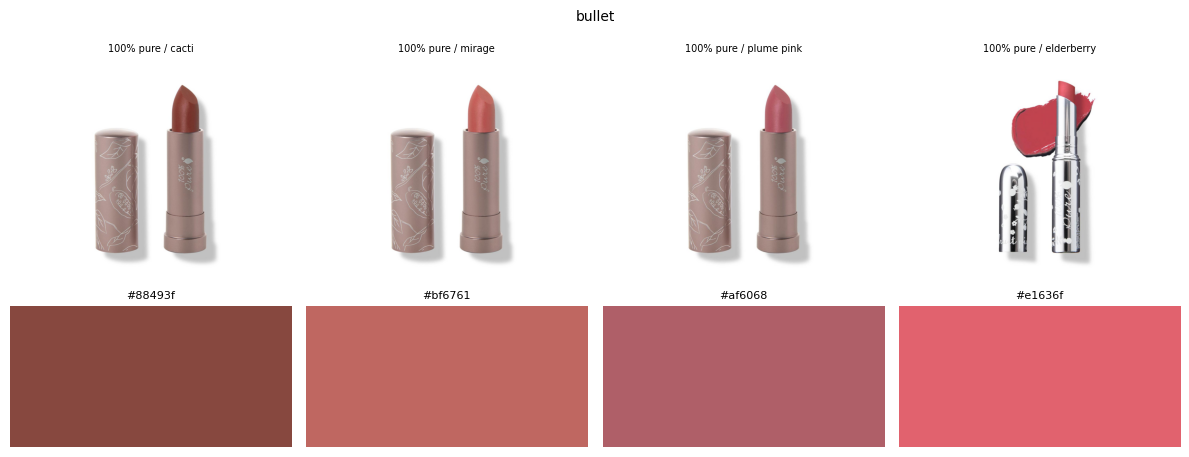

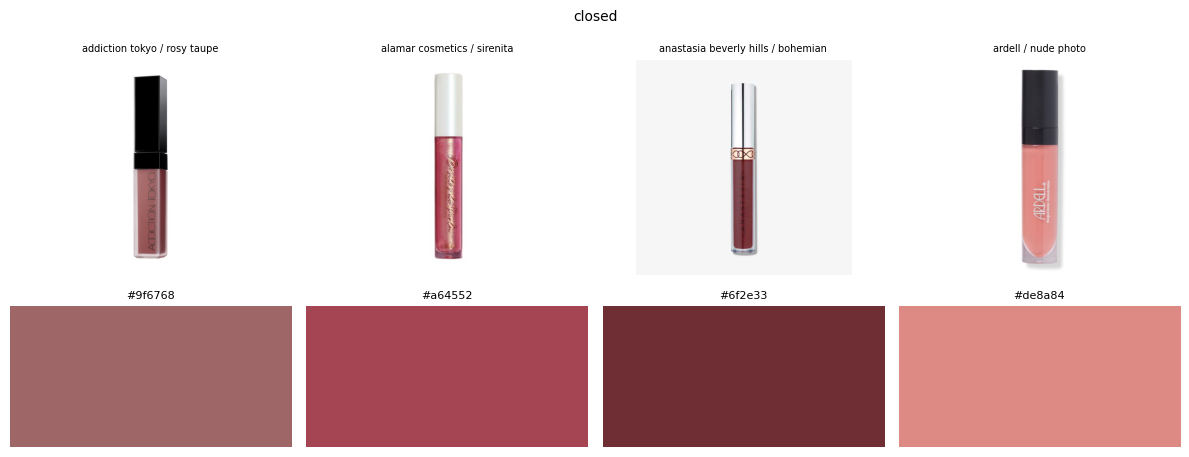

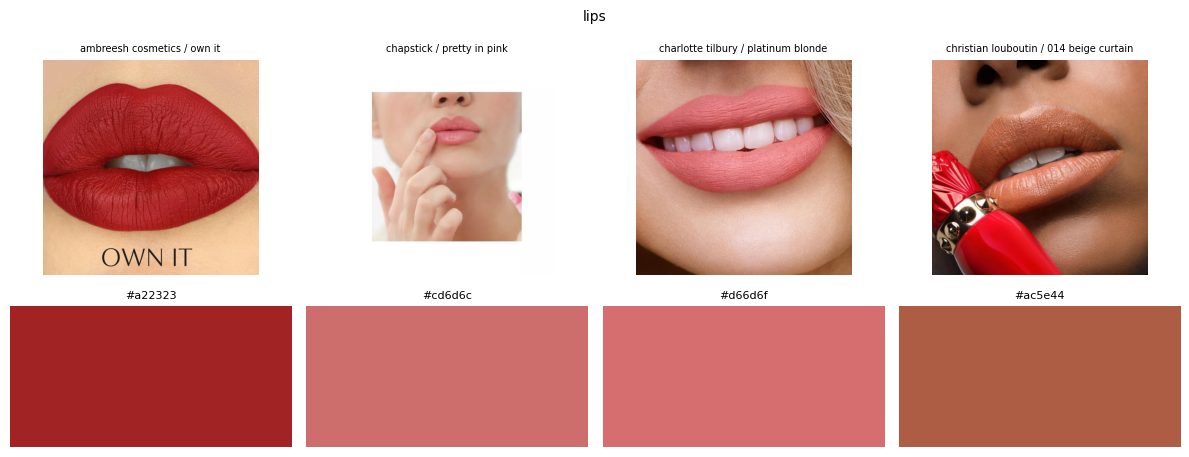

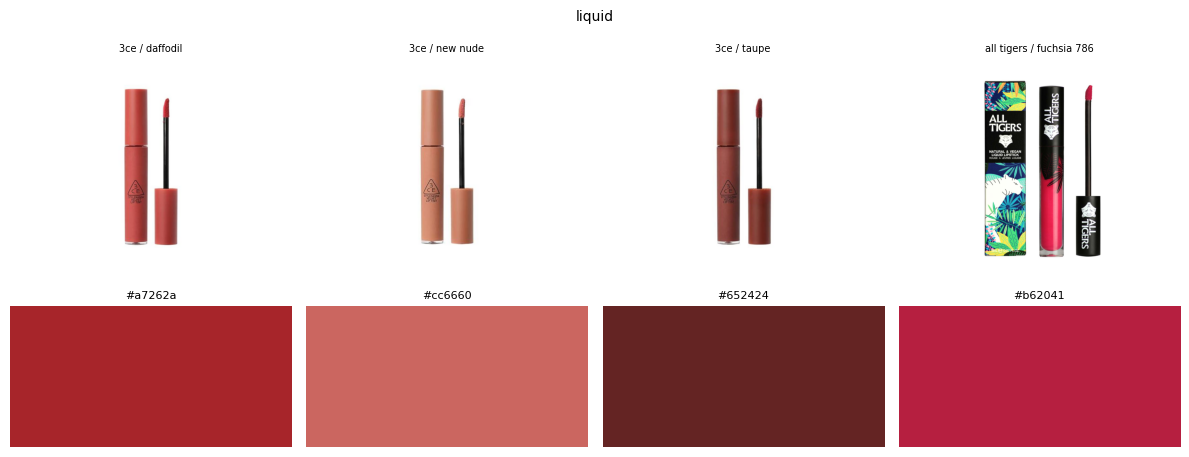

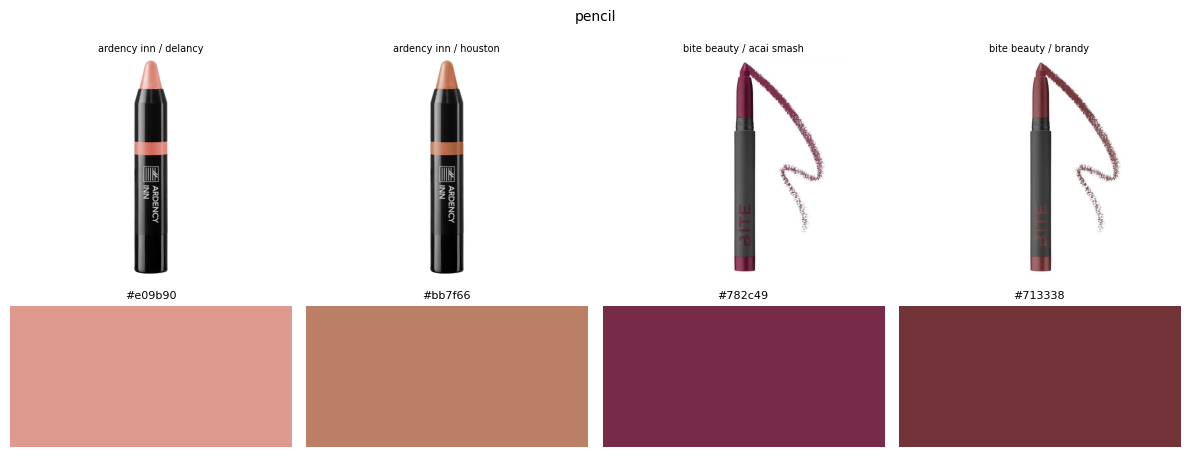

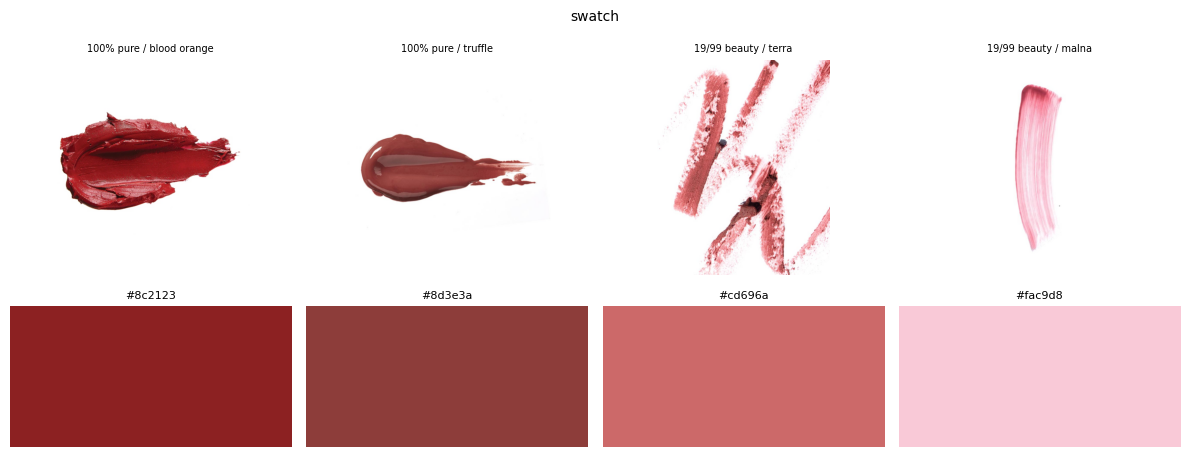

In [13]:
# Sample grid: product image + extracted color swatch (4 per routed category)
n_show = 4

def lab_patch(L, a, b, w=80, h=40):
    rgb = skcolor.lab2rgb(np.array([[[L, a, b]]])).clip(0, 1)
    return np.ones((h, w, 3), dtype=np.float32) * rgb[0, 0]

for label in CLASSES:
    grp = out_final[(out_final['routed_label'] == label) & out_final['L'].notna()].head(n_show).reset_index(drop=True)
    if grp.empty:
        continue
    fig, axes = plt.subplots(2, len(grp), figsize=(len(grp) * 3, 5))
    if len(grp) == 1:
        axes = axes.reshape(2, 1)
    for i, row in grp.iterrows():
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        axes[0, i].imshow(img)
        title = f"{row.get('brand', '')} / {row.get('shade', '')}" if pd.notna(row.get('brand')) else row['img_name'][:30]
        axes[0, i].set_title(title, fontsize=7)
        axes[0, i].axis('off')
        axes[1, i].imshow(lab_patch(row['L'], row['a'], row['b']))
        axes[1, i].set_title(row['hex_color'], fontsize=8)
        axes[1, i].axis('off')
    fig.suptitle(f'{label}', fontsize=10)
    plt.tight_layout()
    plt.show()
